In [1]:
import icarusplot
import uproot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import os

@@ Importing mplstyle from /Users/jskim/lib/icarusplot//icarus_style.mplstyle


In [2]:
NuMIFluxFile = '2024-04-02_ICARUS_g3Chase_PPFX_FHC_flux.root'
NuMIFluxHistName = 'hflux_fhc_numu'

NuMIFluxFile = '2024-04-23_ICARUS_g3Chase_PPFX_flux.root'
NuMIFluxHistName = 'weighted_flux_fhc_numu'

In [3]:
with uproot.open(NuMIFluxFile) as f:

    NuMIFluxHist = f[NuMIFluxHistName]

In [4]:
BNBFluxFile = 'BNB_flux.root'
BNBFluxHistName = 'flux_hist'

In [5]:
with uproot.open(BNBFluxFile) as f:

    BNBFluxHist = f[BNBFluxHistName]

In [6]:
Binning_NuMI = NuMIFluxHist.to_numpy()[1]
BinWidth_NuMI = np.diff(Binning_NuMI)
FluxValue_NuMI = NuMIFluxHist.to_numpy()[0]
Area_NuMI = np.sum(FluxValue_NuMI)

Binning_BNB = BNBFluxHist.to_numpy()[1]
BinWidth_BNB = np.diff(Binning_BNB)
FluxValue_BNB = BNBFluxHist.to_numpy()[0]
Area_BNB = np.sum(FluxValue_BNB)

In [7]:
FluxCut = 0.3

LowArea_NuMI = 0.
for ibin in range(len(Binning_NuMI)-1):
    x_l = Binning_NuMI[ibin]
    x_r = Binning_NuMI[ibin+1]
    x_c = (x_l+x_r)/2.
    if x_c<FluxCut:
       LowArea_NuMI +=  FluxValue_NuMI[ibin]

LowArea_BNB = 0.
for ibin in range(len(Binning_BNB)-1):
    x_l = Binning_BNB[ibin]
    x_r = Binning_BNB[ibin+1]
    x_c = (x_l+x_r)/2.
    if x_c<FluxCut:
       LowArea_BNB +=  FluxValue_BNB[ibin]


print("NuMI low frac = %f"%(LowArea_NuMI/Area_NuMI))
print("BNB low frac = %f"%(LowArea_BNB/Area_BNB))

NuMI low frac = 0.564134
BNB low frac = 0.131915


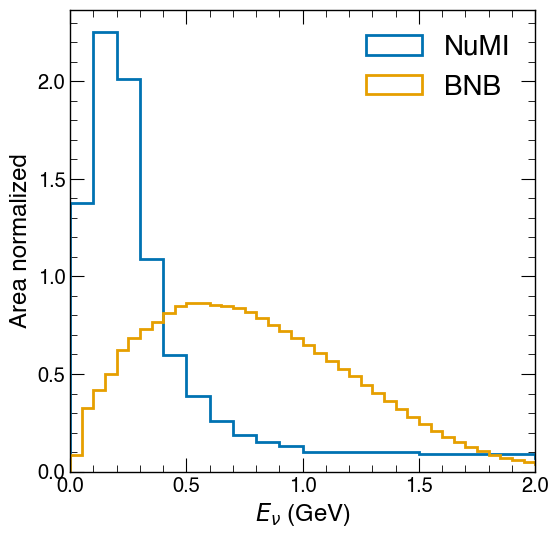

In [8]:
fig, ax = plt.subplots(figsize=(6,6))

ax.hist(
    Binning_NuMI[:-1], 
    bins=Binning_NuMI,
    weights=FluxValue_NuMI/BinWidth_NuMI/Area_NuMI,
    histtype='step',
    label='NuMI',
)

ax.hist(
    Binning_BNB[:-1], 
    bins=Binning_BNB,
    weights=FluxValue_BNB/BinWidth_BNB/Area_BNB,
    histtype='step',
    label='BNB',
)

ax.set_xlabel(r'$E_{\nu}$ (GeV)')
ax.set_xlim(0.,2.0)

ax.set_ylabel('Area normalized')

ax.legend(fontsize=20)

fig.savefig('FluxComparison.pdf', bbox_inches='tight')
